In [2]:
import pandas as pd
from numpy import array,dot
from MDAnalysis.analysis import align
from functions.Sliding_Functions import local_rmsd_plotter,get_significance
from functions.CIF_Functions import make_df_atomlist
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import glob

In [3]:
#               Predictions
###############################################
# select input files
filepaths= glob.glob('cif_files/Predictions/CALCIUMLESS/*/*.cif')
filepaths.extend(glob.glob('cif_files/Predictions/SEEDMATCHED/*_noptms/*.cif'))

# put all predictions in a list as analysable dataframes
grouped_model_list = {}
atomlist = ["CA","N","C"]

for filepath in filepaths:
    df = make_df_atomlist(filepath,atomlist)
    # splitting filepaths to make readable names
    grouped_model_list[filepath.split("fold_")[-1][:-4]] = df

#               Crystal
###############################################
XR_PATH = "cif_files\\Crystals\\7stz (1).cif"
xr_df = make_df_atomlist(XR_PATH,atomlist)

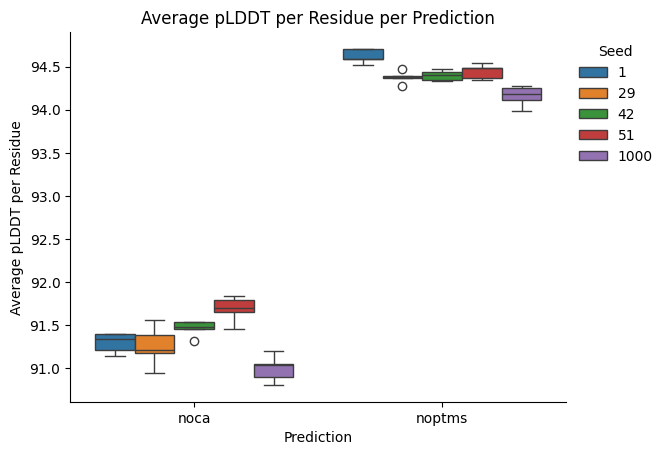

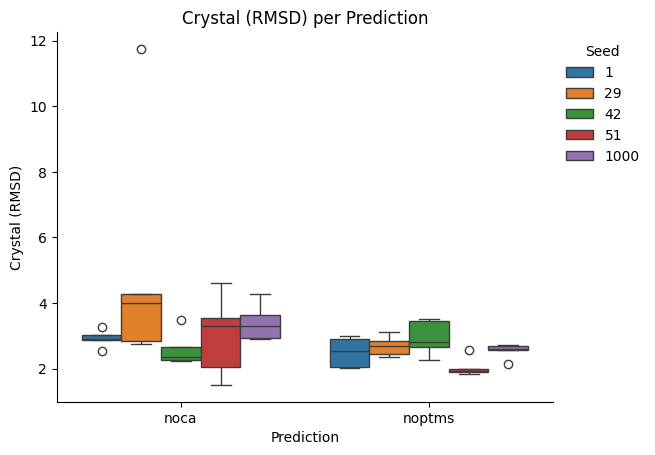

In [4]:
# Comparing Prediction vs Crystal (GLOBAL ALIGNMENT)
rmsdlist = []
for i in list(grouped_model_list.keys()):
    df_a = xr_df
    df_b = grouped_model_list[i]
    x= array(df_a[df_a.columns[10:13]][10:-10]).astype(float)
    x_mean_centered = x - (sum(x)/len(x))
    y= array(df_b[df_b.columns[10:13]][10:-10]).astype(float)
    y_mean_centered = y - (sum(y)/len(y))
    _, rms = align.rotation_matrix(x_mean_centered, y_mean_centered)
    rmsdlist.append(rms)

predlist = [i.split(sep="model")[0].split(sep="_")[-2] for i in list(grouped_model_list.keys())]

seedlist = [filepath.split("seed")[1].split("_")[0] for filepath in filepaths]
plddtavg = [sum(grouped_model_list[i]["B_iso_or_equiv"].astype(float))/len(grouped_model_list[i]["B_iso_or_equiv"].astype(float)) for i in list(grouped_model_list.keys())]

df= pd.DataFrame({"Keys":list(grouped_model_list.keys()),
                  "Prediction":predlist,
                  "Seed":seedlist,
                  "Crystal (RMSD)":rmsdlist,
                  "Average pLDDT per Residue":plddtavg
                  })

x= "Prediction"
y = "Average pLDDT per Residue"
sns.boxplot(data=df,x=x,y=y,hue_order=["1","29","42","51","1000"],hue="Seed")
plt.title(f"{y} per {x}")
plt.legend(title="Seed",frameon=False,bbox_to_anchor=(1.2,1))
sns.despine(offset=0)
plt.show()


x= "Prediction"
y = "Crystal (RMSD)"
sns.boxplot(data=df,x=x,y=y,hue_order=["1","29","42","51","1000"],hue="Seed")
plt.title(f"{y} per {x}")
plt.legend(title="Seed",frameon=False,bbox_to_anchor=(1.2,1))
sns.despine(offset=0)
plt.show()

In [5]:
df.sort_values(by=["Average pLDDT per Residue"])

,Keys,Prediction,Seed,Crystal (RMSD),Average pLDDT per Residue
2,seed1000_noca_model_2,noca,1000,3.302229,90.806284
4,seed1000_noca_model_4,noca,1000,4.281898,90.892765
14,seed29_noca_model_4,noca,29,11.748758,90.947889
3,seed1000_noca_model_3,noca,1000,2.891546,91.039617
0,seed1000_noca_model_0,noca,1000,2.930667,91.049309
9,seed1_noca_model_4,noca,1,3.011004,91.142333
13,seed29_noca_model_3,noca,29,3.990396,91.175049
1,seed1000_noca_model_1,noca,1000,3.624255,91.194494
12,seed29_noca_model_2,noca,29,2.760764,91.215420
5,seed1_noca_model_0,noca,1,2.524107,91.215926


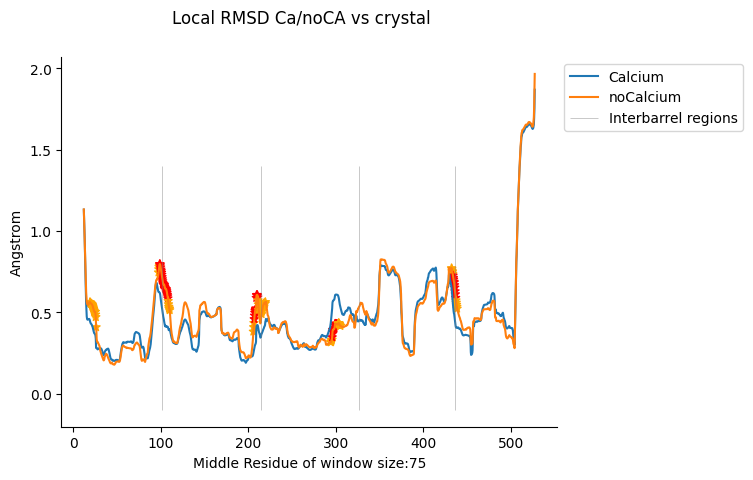

In [6]:
from functions.Sliding_Functions import local_rmsd_plotter
best_ca = grouped_model_list["adnan_seed1_noptms_model_1"]
best_noca = grouped_model_list["seed51_noca_model_1"]
step = 1
win = 75
x,a_y,_ = local_rmsd_plotter(best_ca,xr_df,stepsize=step,win_size=win)
x,b_y,_ = local_rmsd_plotter(best_noca,xr_df,stepsize=step,win_size=win)

colorlist = get_significance(a_y,b_y)

plt.plot(array(x)/3,a_y,label="Calcium")
plt.plot(array(x)/3,b_y,label="noCalcium")
plt.scatter(array(x)/3,b_y,c=colorlist,marker="*",alpha=[1 if i== "red" else 1 if i== "orange" else 0 for i in colorlist])

plt.vlines([102,215,327,436],-.1,1.4,colors="grey",alpha=.5,label="Interbarrel regions",linewidth=.6)
#plt.vlines([126, 204,206, 314, 316, 318,422,424,426],-.1,1.4,colors="red",alpha=1,label="Manose binding residues",linewidth=.6)
plt.suptitle("Local RMSD Ca/noCA vs crystal")
#plt.title(mannwhitneyu(a_y,b_y),color="grey")
plt.xlabel(f"Middle Residue of window size:{win}")
plt.ylabel("Angstrom")
plt.legend(bbox_to_anchor=(1,1))
sns.despine(offset=0)
plt.show()

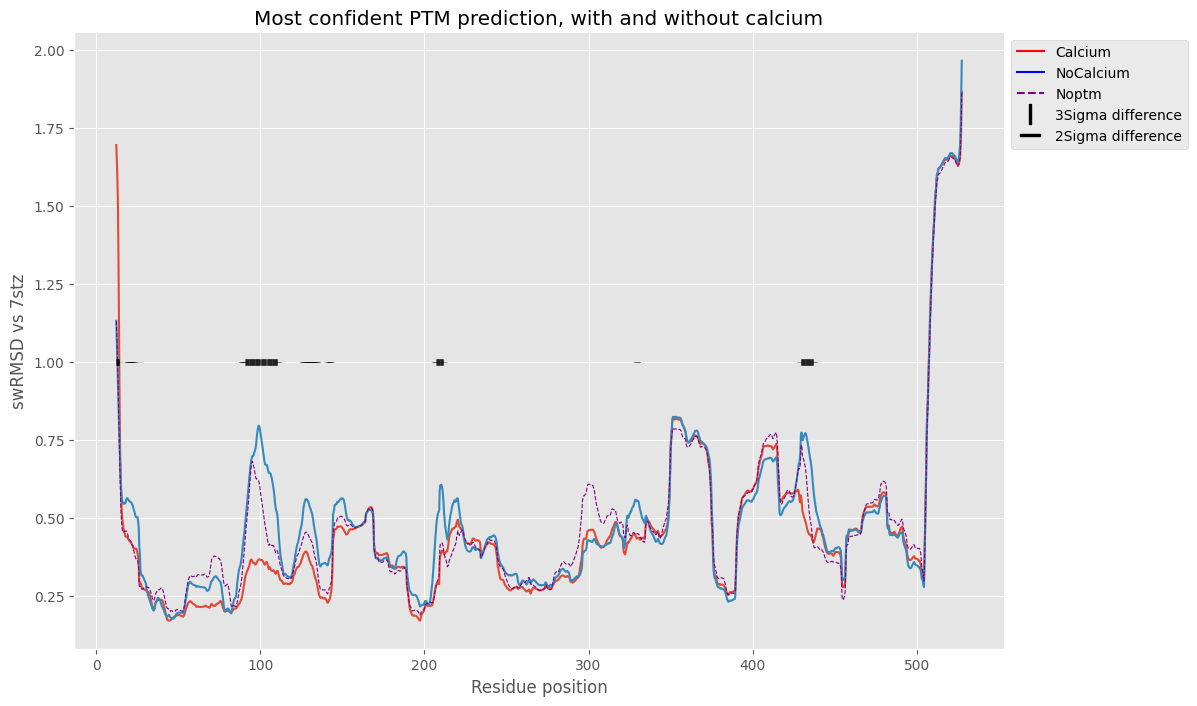

In [10]:
from functions.Sliding_Functions import local_rmsd_plotter
from functions.CIF_Functions import make_df_atomlist
from scipy.stats import mannwhitneyu
import numpy as np
from numpy import array
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib


atomlist = ["CA","C","N"]
best_ca = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed42_ptms/fold_adnan_seed42_ptms_model_3.cif",atomlist)
best_noca = make_df_atomlist("cif_files/Predictions/CALCIUMLESS/fold_seed51_noca/fold_seed51_noca_model_1.cif",atomlist)  
xr_df_CA = make_df_atomlist("cif_files\\Crystals\\7stz (1).cif",atomlist)

noptm_df = make_df_atomlist("cif_files/Predictions/SEEDMATCHED/fold_adnan_seed1_noptms/fold_adnan_seed1_noptms_model_1.cif",atomlist)

step = 1
win = 75

x,a_y,_ = local_rmsd_plotter(best_ca,xr_df_CA,stepsize=step,win_size=win)

x,b_y,_ = local_rmsd_plotter(best_noca,xr_df_CA,stepsize=step,win_size=win)

x,c_y,_ = local_rmsd_plotter(noptm_df,xr_df_CA,stepsize=step,win_size=win)

colorlist= get_significance(a_y,b_y)


plt.style.use(style="ggplot")
fig, ax = plt.subplots(figsize=(12,8))  


# for i,j in [(0,5),(99,14),(212,14),(324,13),(431,13),(532,8)]:
#     ax.add_patch(Rectangle((i,0),j,1,linewidth=1,edgecolor='none',facecolor='grey',alpha=.5))

plt.plot(array(x)/3,a_y,label="Calcium",zorder=1)
plt.plot(array(x)/3,b_y,label="noCalcium",zorder=2)
plt.plot(array(x)/3,c_y,label="noPTM",zorder=3,linestyle="dashed",color="purple",linewidth=.8)
#plt.scatter(array(x)/3,b_y,c=colorlist,marker="*",alpha=[.3 if i== "red" else .3 if i== "orange" else 0 for i in colorlist],zorder=3)

plt.scatter(array(x)/len(atomlist),[1 for _ in a_y],color=["black" if i =="red" else "blue" for i in colorlist],marker="$|$",alpha=[.5 if i== "red" and j%1==0 else 0 for j,i in enumerate(colorlist)],zorder=4,s=20)
plt.scatter(array(x)/len(atomlist),[1 for _ in a_y],color=["black" if i =="orange" else "blue" for i in colorlist],marker="$-$",facecolors=["white" if i =="red" else "none" for i in colorlist],alpha=[.3 if i== "orange" and j%1==0 else 0 for j,i in enumerate(colorlist)],zorder=4,s=20)

#plt.vlines(array([102,215,327,436]),-.1,1.4,colors="grey",alpha=.5,label="Interbarrel regions",linewidth=.8)
#plt.vlines([126, 204,206, 314, 316, 318,422,424,426],-.1,1.4,colors="red",alpha=1,label="Manose binding residues",linewidth=.6)
#plt.suptitle("Local RMSD Ca/noCA vs 7stz")
plt.title("Most confident PTM prediction, with and without calcium")
plt.xlabel(f"Residue position")
plt.ylabel("swRMSD vs 7stz")

legend_elements = [Line2D([0], [0], color="#ff0000", label='Calcium', markersize=15),
                   Line2D([0], [0], color='Blue', label='NoCalcium', markersize=15),
                   Line2D([0], [0], color='purple',linestyle="dashed", label='Noptm', markersize=15),
                   Line2D([0], [0], marker='$|$', color='none', label='3Sigma difference',markerfacecolor='black', markersize=15),
                   Line2D([0], [0], marker='$-$', color='none', label='2Sigma difference',markerfacecolor='black', markersize=15)]

plt.legend(bbox_to_anchor=(1,1),handles=legend_elements)
sns.despine(offset=0)
plt.savefig("fig7.png",bbox_inches="tight")
plt.show()